In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from src.data_processor import add_technical_indicators, extract_regimes
from src.environment import OptimalExecutionEnv

In [2]:
df_raw = pd.read_csv("data/BTCUSDT_1h_FINAL.csv")
df_enriched = add_technical_indicators(df_raw)
df_final, transmat = extract_regimes(df_enriched)

Model is not converging.  Current: 578633.4478221749 is not greater than 578641.9232816672. Delta is -8.475459492299706


In [3]:
train_df = df_final[df_final['Open_Time'] < '2024-01-01']
test_df = df_final[df_final['Open_Time'] >= '2024-01-01']

In [4]:
env = OptimalExecutionEnv(train_df, transmat)
model = PPO("MlpPolicy", env, verbose=1)
print("Entraînement en cours")
model.learn(total_timesteps=50000)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Entraînement en cours
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.55     |
|    ep_rew_mean     | 238      |
| time/              |          |
|    fps             | 799      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 6.87         |
|    ep_rew_mean          | 231          |
| time/                   |              |
|    fps                  | 331          |
|    iterations           | 2            |
|    time_elapsed         | 12           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0023849763 |
|    clip_fraction        | 0.0083       |
|    clip_range           | 

In [5]:
def test_agent(model, test_df, transmat, n_episodes=5):
    test_env = OptimalExecutionEnv(test_df, transmat)
    all_revenues = []

    for ep in range(n_episodes):
        obs, _ = test_env.reset()
        done = False
        ep_revenue = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, _ = test_env.step(action)
            ep_revenue += reward * 1000 # On remet à l'échelle réelle
        all_revenues.append(ep_revenue)
        print(f"Épisode {ep+1}: Revenu Total = {ep_revenue:.2f} USDT")

    # Petit graphique simple des revenus de test
    plt.bar(range(1, n_episodes+1), all_revenues)
    plt.title("Performance de l'Agent sur le set de Test")
    plt.ylabel("Revenu Total (USDT)")
    plt.show()



Évaluation de l'agent
Épisode 1: Revenu Total = 657137.48 USDT
Épisode 2: Revenu Total = 1090053.87 USDT
Épisode 3: Revenu Total = 650977.65 USDT
Épisode 4: Revenu Total = 649496.93 USDT
Épisode 5: Revenu Total = 972410.00 USDT


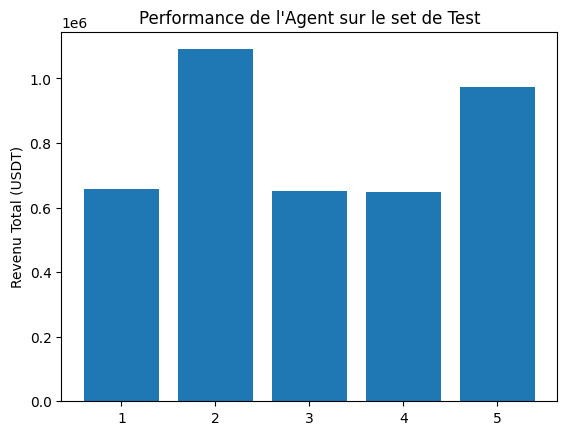

In [6]:
print("\nÉvaluation de l'agent")
test_agent(model, test_df, transmat)